# GAIN Corpus — Exploration

Free-form analysis notebook. Start from what you know about the domain —
write queries that answer the questions your external knowledge suggests.
When something looks anomalous, open a case in `investigations/`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from IPython.display import display, Image
warnings.filterwarnings('ignore')

DB_PATH = 'db/gain.db'
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

def q(sql, params=()):
    return pd.read_sql_query(sql, conn, params=params)

def pct(part, whole, decimals=1):
    return f"{part / whole * 100:.{decimals}f}%"

plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.alpha': 0.4,
})

# Quick table listing — run this first to see what's available
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
)
display(tables)

,name
0,committees
1,honoree_member_map
2,house_activities
3,house_activities_fts
4,house_activities_fts_config
5,house_activities_fts_content
6,house_activities_fts_data
7,house_activities_fts_docsize
8,house_activities_fts_idx
9,house_affiliated_orgs


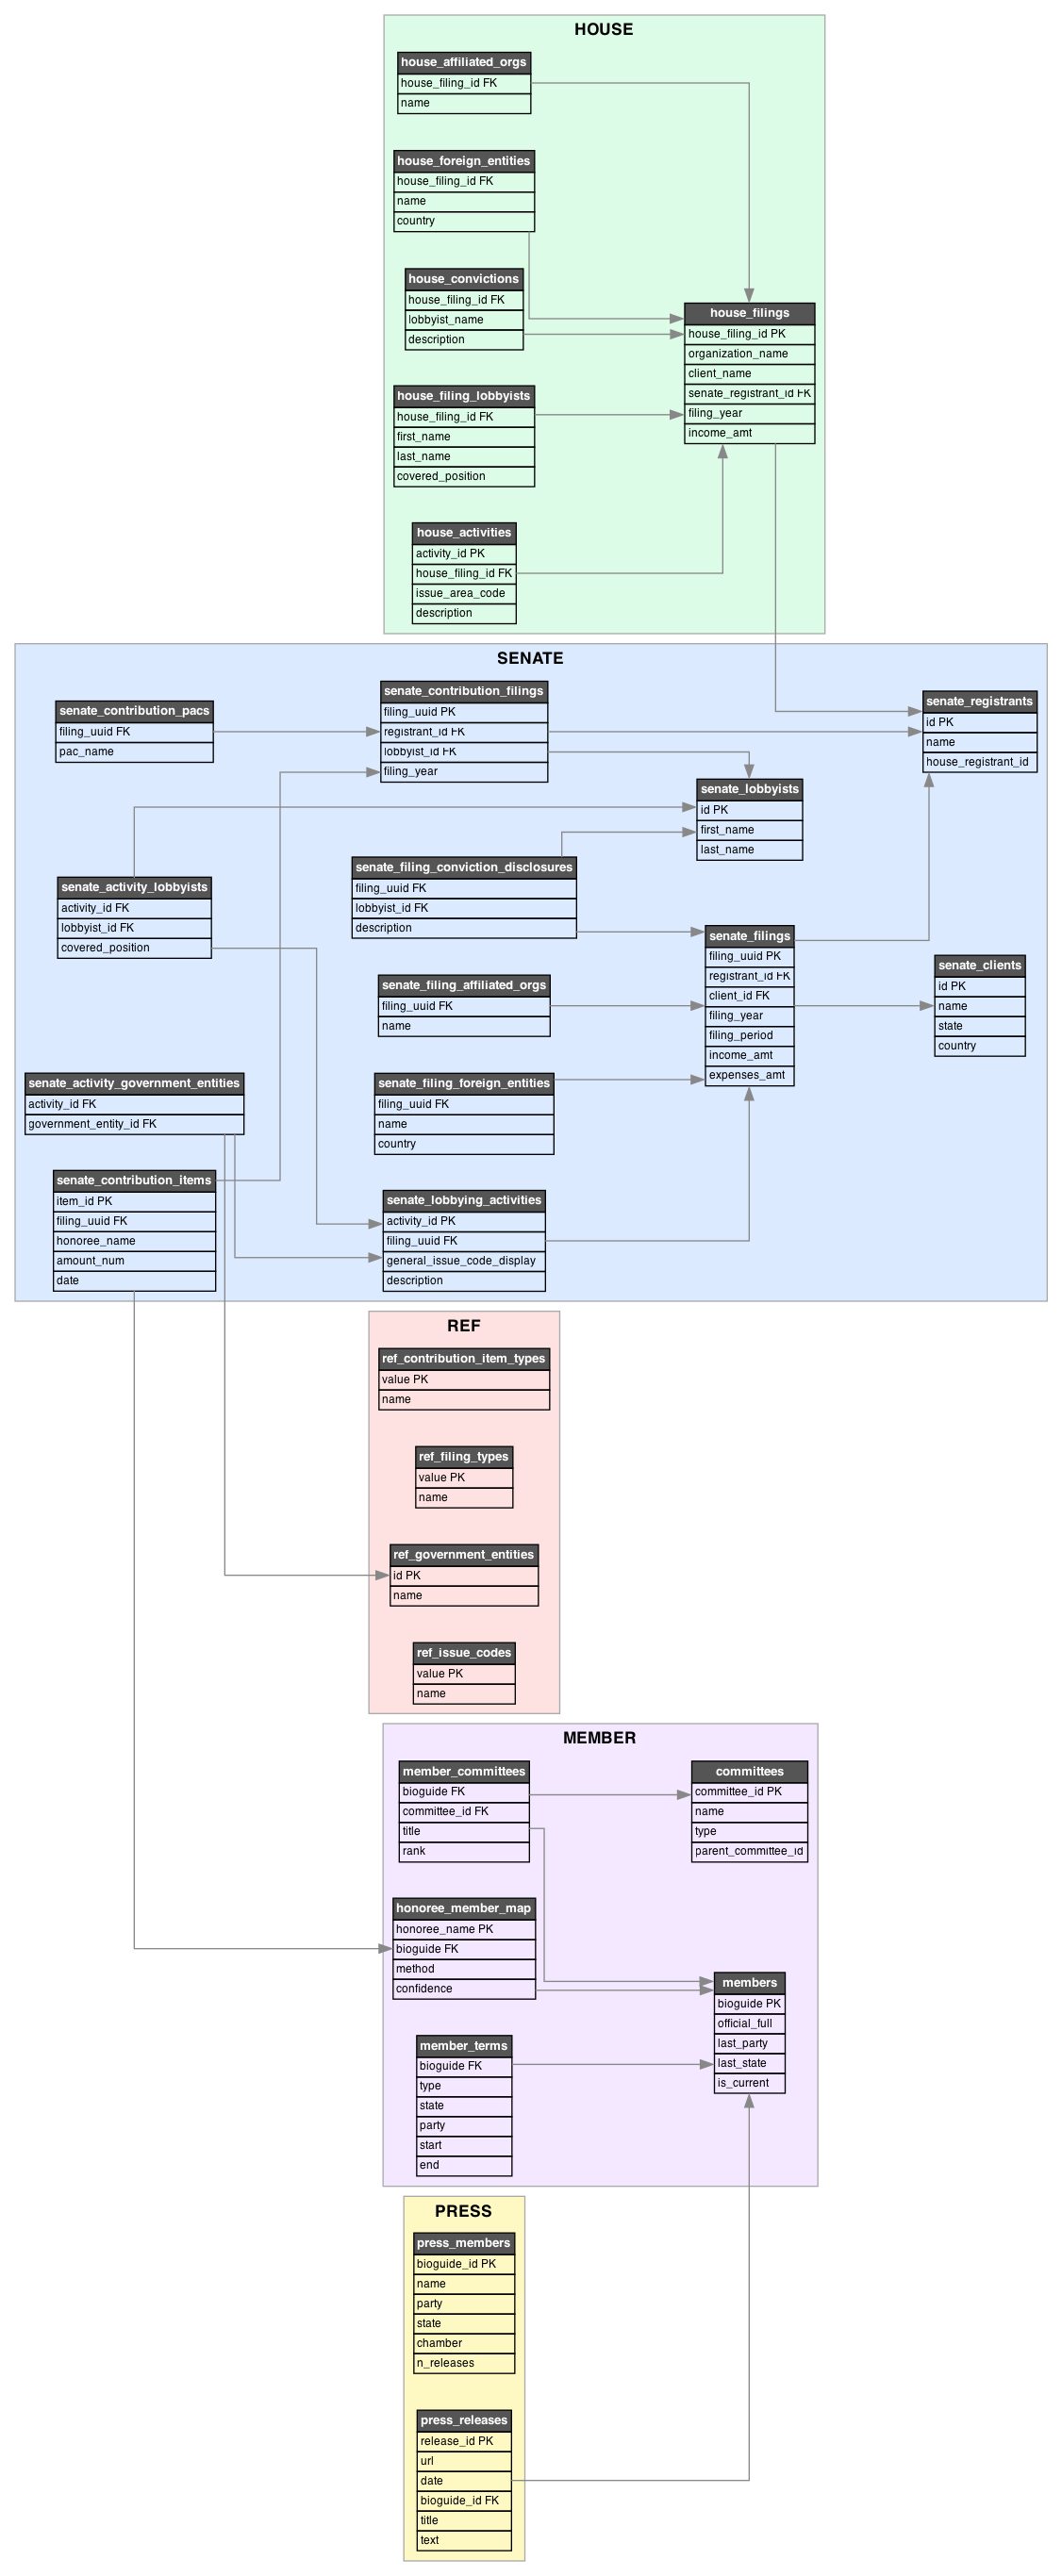

In [113]:
Image('schema_diagram.png') 

Emma's notes. Things of interest to me:
- Covered positions and what/who these lobbyists are lobbying for
- Conviction records and what/who the convicted people are lobbying for
- Say vs pay, we join press releases of specific members to the contributions they receive.
- How to mine the press releases for language we're interested in, track trends in spending and press releases on specific issues

In [6]:
pd.set_option('display.max_columns', None)

Show how many megabytes each table takes up, as guidance if I want to load them into RAM.

In [3]:
q("""
  SELECT name, 
         SUM(payload) as bytes,
         ROUND(SUM(payload) / 1048576.0, 1) as mb
  FROM dbstat
  WHERE name NOT LIKE 'sqlite_%'
  GROUP BY name
  ORDER BY bytes DESC
  """).head(20)

,name,bytes,mb
0,press_releases,500904771,477.7
1,press_fts_content,452607822,431.6
2,house_activities,236248285,225.3
3,press_fts_data,234997809,224.1
4,senate_lobbying_activities,233380785,222.6
5,house_activities_fts_content,226986958,216.5
6,senate_activities_fts_content,186453915,177.8
7,senate_filings,153639132,146.5
8,house_filings,121856951,116.2
9,house_activities_fts_data,98623079,94.1


In [10]:
# look at a few rows of an individual table
q("SELECT * FROM senate_lobbying_activities LIMIT 5")

,activity_id,filing_uuid,seq,general_issue_code,general_issue_code_display,description,foreign_entity_issues
0,1,a71de50d-ce0b-4056-b699-05368ec543ba,0,DEF,Defense,Defense Manufacturing and engineering,None
1,2,00ec8a9e-35d6-4bcf-a43a-da032d3723bc,0,AGR,Agriculture,USDA barley research funding; USDA farm progra...,None
2,3,606530b1-f1a6-4c86-891c-1b19c413a103,0,HCR,Health Issues,FDA regulation of medical products,None
3,4,da28266e-90ad-46b5-aa54-bcf6fdfb5c36,0,ENV,Environment/Superfund,Legislative and Regulatory Issues regarding an...,None
4,5,da28266e-90ad-46b5-aa54-bcf6fdfb5c36,1,TAX,Taxation/Internal Revenue Code,Legislative and Regulatory Issues regarding an...,None


# FTS capabilities of press release data

In [8]:
# using the FTS capabilities
q("SELECT * FROM press_fts WHERE press_fts MATCH 'insulin' LIMIT 5")

,title,text,release_id
0,SCHUMER DOUBLES DOWN ON PUSH TO REDUCE OUTRAGE...,Standing Alongside Rochester Advocates Who Nee...,2297
1,SCHUMER DOUBLES DOWN ON PUSH TO REDUCE OUTRAGE...,Standing Alongside WNY-ers Who Need Insulin Da...,2298
2,SCHUMER DOUBLES DOWN ON PUSH TO REDUCE OUTRAGE...,Standing Alongside Central New York Residents ...,2417
3,SCHUMER DOUBLES DOWN ON PUSH TO REDUCE OUTRAGE...,Standing Alongside Albany Residents Who Need I...,2418
4,"Representatives Craig, Kildee and McBath Intro...","WASHINGTON, DC — Today, U.S. Representatives A...",2449


In [9]:
# using the FTS capabilities w/ join back to the metadata
q("""
  SELECT p.date, p.member_name, p.title
  FROM press_fts f
  JOIN press_releases p ON p.release_id = f.release_id
  WHERE press_fts MATCH 'insulin'
  ORDER BY p.date DESC
  LIMIT 10
  """)

,date,member_name,title
0,2026-03-31,Raphael G. Warnock,"Warnock, Young Introduce Bipartisan Legislatio..."
1,2026-03-27,Jeanne Shaheen,Support Grows for Bipartisan Bill to Cap Month...
2,2026-03-25,Susan M. Collins,"Senators Collins, Shaheen, Warnock, Kennedy Un..."
3,2026-03-25,Jeanne Shaheen,"Senators Shaheen, Collins, Warnock, Kennedy Un..."
4,2026-03-25,Raphael G. Warnock,"Warnock, Colleagues Introduce Bipartisan Legis..."
5,2026-03-24,H. Morgan Griffith,"Griffith Announces $132,885 HHS Grant to Virgi..."
6,2026-03-19,Susan M. Collins,"Senators Collins, Shaheen Preview INSULIN Act ..."
7,2026-03-11,Gabe Vasquez,Rep. Gabe Vasquez Champions Bill to Cap Prescr...
8,2026-03-11,Susan M. Collins,"Senators Collins, Shaheen Introduce Bipartisan..."
9,2026-03-11,Jeanne Shaheen,Senators Shaheen and Collins Introduce Biparti...


In [15]:
q("SELECT * FROM senate_lobbying_activities LIMIT 10")

,activity_id,filing_uuid,seq,general_issue_code,general_issue_code_display,description,foreign_entity_issues
0,1,a71de50d-ce0b-4056-b699-05368ec543ba,0,DEF,Defense,Defense Manufacturing and engineering,None
1,2,00ec8a9e-35d6-4bcf-a43a-da032d3723bc,0,AGR,Agriculture,USDA barley research funding; USDA farm progra...,None
2,3,606530b1-f1a6-4c86-891c-1b19c413a103,0,HCR,Health Issues,FDA regulation of medical products,None
3,4,da28266e-90ad-46b5-aa54-bcf6fdfb5c36,0,ENV,Environment/Superfund,Legislative and Regulatory Issues regarding an...,None
4,5,da28266e-90ad-46b5-aa54-bcf6fdfb5c36,1,TAX,Taxation/Internal Revenue Code,Legislative and Regulatory Issues regarding an...,None
5,6,da28266e-90ad-46b5-aa54-bcf6fdfb5c36,2,ENG,Energy/Nuclear,Legislative and Regulatory Issues regarding an...,None
6,7,1cb6546a-74e5-489a-aa65-ffd600472919,0,TRA,Transportation,Transportation lobbying,None
7,8,8e8fdd52-6697-4bff-b691-68316342e1d3,0,DEF,Defense,Defense appropriations and NDAA,None
8,9,b500f55d-10df-4da8-9797-f3a03caabc5f,0,ENG,Energy/Nuclear,"H.R. 3684, Infrastructure Investment and Jobs ...",None
9,10,b500f55d-10df-4da8-9797-f3a03caabc5f,1,UTI,Utilities,"H.R. 3684, Infrastructure Investment and Jobs ...",None


In [13]:
q("SELECT * FROM senate_activity_lobbyists LIMIT 5")

,activity_id,lobbyist_id,covered_position,is_new
0,1,68687,None,1
1,2,139162,None,1
2,2,44576,None,1
3,3,115899,None,1
4,4,67658,None,1


In [18]:
q("SELECT * FROM senate_filings LIMIT 5")

,filing_uuid,filing_type,filing_type_display,filing_year,filing_period,filing_period_display,registrant_id,client_id,income,income_amt,expenses,expenses_amt,expenses_method,expenses_method_display,client_effective_date,posted_by_name,dt_posted,termination_date,url,filing_document_url
0,a71de50d-ce0b-4056-b699-05368ec543ba,RR,Registration,2022,first_quarter,1st Quarter (Jan 1 - Mar 31),401103986,213170,None,None,None,None,None,None,2022-01-01,Brian Dearing,2022-01-01T14:12:24-05:00,None,https://lda.senate.gov/api/v1/filings/a71de50d...,https://lda.senate.gov/filings/public/filing/a...
1,00ec8a9e-35d6-4bcf-a43a-da032d3723bc,RA,Registration - Amendment,2022,first_quarter,1st Quarter (Jan 1 - Mar 31),2822,103601,None,None,None,None,None,None,2022-01-01,Ashley McFarland,2022-01-03T11:28:38-05:00,None,https://lda.senate.gov/api/v1/filings/00ec8a9e...,https://lda.senate.gov/filings/public/filing/0...
2,606530b1-f1a6-4c86-891c-1b19c413a103,RR,Registration,2022,first_quarter,1st Quarter (Jan 1 - Mar 31),401106349,213177,None,None,None,None,None,None,2022-01-03,Cara E Tenenbaum,2022-01-03T15:28:25-05:00,None,https://lda.senate.gov/api/v1/filings/606530b1...,https://lda.senate.gov/filings/public/filing/6...
3,da28266e-90ad-46b5-aa54-bcf6fdfb5c36,RR,Registration,2022,first_quarter,1st Quarter (Jan 1 - Mar 31),401104738,213179,None,None,None,None,None,None,2022-01-01,Darren Peters,2022-01-03T18:50:59-05:00,None,https://lda.senate.gov/api/v1/filings/da28266e...,https://lda.senate.gov/filings/public/filing/d...
4,1cb6546a-74e5-489a-aa65-ffd600472919,RR,Registration,2022,first_quarter,1st Quarter (Jan 1 - Mar 31),401104213,213178,None,None,None,None,None,None,2022-01-03,Britton Clarke,2022-01-03T19:19:48-05:00,None,https://lda.senate.gov/api/v1/filings/1cb6546a...,https://lda.senate.gov/filings/public/filing/1...


In [16]:
q("SELECT * FROM house_filings LIMIT 5")

,house_filing_id,doc_type,filing_year,filing_period,report_year,report_type,reg_type,organization_name,contact_prefix,contact_first_name,contact_last_name,address_1,address_2,city,state,zip,country,principal_city,principal_state,principal_zip,principal_country,registrant_general_description,self_select,client_name,client_govt_entity,client_address,client_city,client_state,client_zip,client_country,client_general_description,senate_id,senate_registrant_id,senate_client_suffix,house_id,income,income_amt,expenses,expenses_amt,expenses_method,no_lobbying,termination_date,effective_date,printed_name,signed_date,imported,pages,source_file
0,301373619,LD2,2022,Q1,2022,Q1,None,National Indian Gaming Association,None,None,None,"224 2nd Street, SE",NaN,Washington,DC,20003,USA,None,None,None,None,None,Y,National Indian Gaming Association,N,None,None,None,None,None,None,61777-12,61777,12,354220000,NaN,NaN,42000.00,42000.0,A,NaN,NaN,None,Danielle Her Many Horses,4/27/2022 11:02:35 AM,Y,3,data/house/2022_1stQuarter_XML/301373619.xml
1,301364365,LD2,2022,Q1,2022,Q1,None,Ernst & Young LLP (Washington Council Ernst & ...,None,None,None,"1101 New York Avenue, NW",Suite 400,Washington,DC,20005,USA,None,None,None,None,None,N,New York Life Insurance Company,N,None,None,None,None,None,None,57475-1005421,57475,1005421,351850241,70000.00,70000.0,NaN,NaN,NaN,NaN,NaN,None,Jeffrey Levey,4/20/2022 1:59:34 AM,Y,3,data/house/2022_1stQuarter_XML/301364365.xml
2,301374176,LD2,2022,Q1,2022,Q1,None,"RIVERSIDE STRATEGIC SOLUTIONS, LLC",None,None,None,8622 Buckboard Drive,NaN,ALEXANDRIA,VA,22308,USA,None,None,None,None,None,N,Atchison Amelia Earhart Foundation,N,None,None,None,None,None,None,401104895-51,401104895,51,440550005,18000.00,18000.0,NaN,NaN,NaN,NaN,NaN,None,Kevin Jones,5/5/2022 11:53:02 AM,Y,3,data/house/2022_1stQuarter_XML/301374176.xml
3,301372507,LD2,2022,Q1,2022,Q1,None,"INNOVATIVE FEDERAL STRATEGIES, LLC",None,None,None,511 C Street NE,NaN,WASHINGTON,DC,20002,USA,None,None,None,None,None,N,Northrop Grumman Corporation,N,None,None,None,None,None,None,10800-1002350,10800,1002350,318220186,50000.00,50000.0,NaN,NaN,NaN,NaN,NaN,None,Letitia White,4/20/2022 10:56:13 PM,Y,5,data/house/2022_1stQuarter_XML/301372507.xml
4,301343902,LD2,2022,Q1,2022,1T,None,Haley & Associates,None,None,None,PO Box 384,NaN,Royal Oak,MD,21662,USA,None,None,None,None,None,N,CALIFORNIA WALNUT COMMISSION,N,None,None,None,None,None,None,17328-48,17328,48,300580002,NaN,NaN,NaN,NaN,NaN,Y,1/1/2022,None,Daniel Haley,4/6/2022 3:08:09 PM,Y,2,data/house/2022_1stQuarter_XML/301343902.xml


In [20]:
q("SELECT * FROM senate_clients LIMIT 5")

,id,client_id,name,general_description,client_government_entity,client_self_select,state,state_display,country,ppb_state,ppb_country
0,44400,44400,"BLUECROSS BLUESHIELD OF TENNESSEE, INC.",Health benefit plan company,None,0,TN,Tennessee,US,TN,US
1,44401,44401,"ID.ME, INC.","Software as a service, digital identity verifi...",None,0,VA,Virginia,US,VA,US
2,44402,44402,SECURITIES INDUSTRY AND FINANCIAL MARKETS ASSO...,Financial services industry trade association.,None,0,DC,District of Columbia,US,DC,US
3,44407,44407,BELL LEGAL GROUP,Law Firm,None,0,SC,South Carolina,US,SC,US
4,44408,44408,INSTITUTE FOR ADVANCED CLINICAL TRIALS FOR CHI...,Research Organization,None,0,MD,Maryland,US,MD,US


# Convictions

In [23]:
q("SELECT * FROM house_convictions LIMIT 5").values

array([[1, '301371378', 'Kevin Ring', '11/15/2010',
        'Federal convictions: three counts of honest services wire fraud; one count of paying a gratuity to a public official; and one count of conspiracy to commit honest services fraud.'],
       [2, '301356676', 'Rich Juliano', '10/10/2006',
        'U.S. District Court (ND IL), 18 U.S.C. 1341 (1 count)'],
       [3, '301374629', 'C. McClain Haddow', '09/15/1987',
        '9/15/1987, U.S. District Court, 18 U.S.C. Section 208(a), conflict of interest (2 counts)'],
       [4, '301372310', 'Michael Brown', '6/10/2013',
        'United States District Court for the District of Columbia, 18 U.S.C.201(b)(2)(A)'],
       [5, '301374628', 'C. McClain Haddow', '09/15/1987',
        '9/15/1987, U.S. District Court, 18 U.S.C. Section 208(a), conflict of interest (2 counts)']],
      dtype=object)

In [26]:
senate_convictions = q("""
  SELECT 
      l.first_name, l.last_name,
      d.description,
      r.name as registrant,
      c.name as client,
      f.filing_year, f.filing_period,
      d.filing_uuid
  FROM senate_filing_conviction_disclosures d
  JOIN senate_filings f ON f.filing_uuid = d.filing_uuid
  JOIN senate_registrants r ON r.id = f.registrant_id
  JOIN senate_clients c ON c.id = f.client_id
  JOIN senate_lobbyists l ON l.id = d.lobbyist_id
  ORDER BY l.last_name, l.first_name
  """)

In [30]:
(senate_convictions["first_name"] + " " + senate_convictions["last_name"]).value_counts()

JACK BURKMAN            621
JACOB WOHL              239
LANIER AVANT             96
MCCLAIN HADDOW           95
ROGER STONE              23
RICHARD JULIANO          17
C PATTI                  16
JAMES MILLER             11
PAUL SUPLIZIO             8
MICHAEL BROWN             7
KEVIN RING                7
LAWRENCE SMITH            5
HAROLD HANSON             4
ROD BLAGOJEVICH           2
MORRIS THOMAS, JD         2
DUNCAN HUNTER             1
DONAVAN JONES             1
CHRISTOPHER PETRELLA      1
Name: count, dtype: int64

In [27]:
house_convictions = q("""
  SELECT
      c.lobbyist_name,
      c.date,
      c.description,
      f.organization_name as registrant,
      f.client_name,
      f.filing_year, f.filing_period,
      f.
      c.house_filing_id
  FROM house_convictions c
  JOIN house_filings f ON f.house_filing_id = c.house_filing_id
  ORDER BY c.lobbyist_name
  """)

In [32]:
house_convictions

,lobbyist_name,date,description,registrant,client_name,filing_year,filing_period,house_filing_id
0,NaN,NaN,NaN,Hogan Lovells US LLP,Growth Energy,2023,Q2,301491145
1,C McClain Haddow,09/15/1987,"U.S. District Court, 18 U.S.C. Section 208(a),...","Upstream Consulting, Inc.",Arizona State University,2022,Q1,301374631
2,C McClain Haddow,09/15/1987,"U.S. District Court, 18 U.S.C. Section 208(a),...","Upstream Consulting, Inc.",Zions Therapeutics,2022,Q1,301374632
3,C McClain Haddow,09/15/1987,"U.S. District Court, 18 U.S.C. Section 208(a),...","Upstream Consulting, Inc.",Zions Therapeutics,2022,Q2,301396799
4,C McClain Haddow,09/15/1987,"U.S. District Court, 18 U.S.C. Section 208(a),...","Upstream Consulting, Inc.",Arizona State University,2022,Q2,301396798
...,...,...,...,...,...,...,...,...
1155,Roger Stone Jr.,11/15/2019,"Obstruction of Proceeding, False Statements, W...","DRAKE VENTURES, LLC",Tunica-Biloxi Tribe of Louisiana,2025,Q4,301833431
1156,Roger Stone Jr.,11/15/2019,"Obstruction of Proceeding, False Statements, W...","DRAKE VENTURES, LLC",Tunica-Biloxi Tribe of Louisiana,2025,REG,301748341
1157,Roger Stone Jr.,11/15/2019,"11/15/2019, Obstruction of Proceeding, False S...","DRAKE VENTURES, LLC","Infinite Power Holdings, Inc.",2026,REG,301845676
1158,Roger Stone Jr.,11/15/2019,"11/15/2019, Obstruction of Proceeding, False S...","DRAKE VENTURES, LLC","Ecto World, LLC",2026,REG,301845674


In [33]:
house_convictions["lobbyist_name"].value_counts()

lobbyist_name
Jack Burkman            623
Jacob Wohl              240
Lanier Avant             96
C. McClain Haddow        63
C McClain Haddow         19
Rich Juliano             17
C. James Patti           16
C.McClain Haddow         13
Roger Stone Jr.          11
James Miller             10
Paul E Suplizio           8
Kevin Ring                7
Michael Brown             7
Harold Hanson             6
Lawrence J. Smith         5
Rod Blagojevich           4
Morris Thomas             3
Roger Stone               3
Rod  Blagojevich          2
Roger Stone Jr            2
Christopher Petrella      1
Donavan Jones             1
Duncan Hunter             1
Roger  Stone Jr           1
Name: count, dtype: int64

There's very few unique convicted lobbyists. The top ones by filing count are Jack Burkman and Jacob Wohl, who apparently are notorious conspiracy theorists and fraudsters, and Lanier Avant, a Dem who's been convicted of tax fraud. 

In [41]:
# see who their clients are
senate_convictions[senate_convictions["last_name"] == "BURKMAN"]["client"].value_counts().head(20)

client
PATRICIA AND SCOTT FERRELL (404-457-4969)    15
LIBERTY BUILDERS                             15
RHINO, INC.                                  15
HOOPS AND FITNESS                            14
DARCO CONSTRUCTION                           14
DOCTOR RICHARD GOULDING                      14
ROARK FARMS (BOB ROARK 719-337-4182)         14
ADDING TO INC.                               14
MOCHA MAN COFFEE                             14
PJM POWER VENTURES                           14
KEITH LY                                     13
JENNIFER BANMILLER                           13
CARR MANAGEMENT GROUP LLC                    13
PATE DANE                                    12
ACT INC                                      12
VIVCOR SYSTEMS INC.                          12
HUFF STRATEGIES                              11
CLEANWURX INC                                11
BLUE MOON OPERATING                          10
BIOCARE PHARMACY                             10
Name: count, dtype: int64

In [45]:
senate_convictions[senate_convictions["last_name"] == "WOHL"]["client"].value_counts()

client
LIBERTY BUILDERS                    15
RHINO, INC.                         15
DARCO CONSTRUCTION                  14
MOCHA MAN COFFEE                    14
JENNIFER BANMILLER                  13
CARR MANAGEMENT GROUP LLC           13
ACT INC                             12
DANISA GROUP LLC                     9
HAMILTON STAFFING SOLUTIONS          9
JOBY WEEKS                           9
ROSEVILLE SPORTWORLD INC.            8
CHARLES WARREN SENS                  8
CYPRESS HOME DEVELOPMENTS            8
STEVE WARNECKE                       8
TIM MCPHEE                           8
JLGC INC                             7
MARLIN DARRAH                        7
LAKELAND GROUP INC                   6
BOSS SECURITY GLASS                  5
PRAFUL DOSHI                         5
DR. JOSEPH POBER                     5
RENEE OIL DYNAMICS                   5
JOSEPH SCHWARTZ                      5
JOSELITO MOLINA                      4
CHRISTOPHER QUINN                    4
KYLE STEARNS      

In [39]:
senate_convictions[senate_convictions["last_name"] == "AVANT"]["client"].value_counts()

client
SEAFARERS POLITICAL ACTIVITY DONATION    32
THE GEO GROUP                            32
CITY OF GREENVILLE, MISSISSIPPI          32
Name: count, dtype: int64

In [42]:
q("""
  SELECT id, name 
  FROM senate_clients 
  WHERE name GLOB '*[0-9][0-9][0-9]-[0-9][0-9][0-9]*'
     OR name GLOB '*([0-9][0-9][0-9])*'
  """)

,id,name
0,206430,BERKEN ENERGY LLC; KEN NEWMAN 512-777-0000
1,72122,"FL2024-008, INC."
2,168647,PATRICIA AND SCOTT FERRELL (404-457-4969)
3,204656,PETER POCKLINGTON (760) 861-4082
4,204653,ROARK FARMS (BOB ROARK 719-337-4182)
5,168664,STEVE MARKHAM/RADICAL HOPE LLC 817-360-4294


In [46]:
q("""
  SELECT DISTINCT c.id, c.name as client_name, r.name as registrant, l.first_name, l.last_name
  FROM senate_clients c
  JOIN senate_filings f ON f.client_id = c.id
  JOIN senate_registrants r ON r.id = f.registrant_id
  JOIN senate_lobbying_activities a ON a.filing_uuid = f.filing_uuid
  JOIN senate_activity_lobbyists al ON al.activity_id = a.activity_id
  JOIN senate_lobbyists l ON l.id = al.lobbyist_id
  WHERE c.name GLOB '*[0-9][0-9][0-9]-[0-9][0-9][0-9]*'
     OR c.name GLOB '*([0-9][0-9][0-9])*'
  """)

,id,client_name,registrant,first_name,last_name
0,206430,BERKEN ENERGY LLC; KEN NEWMAN 512-777-0000,J M BURKMAN & ASSOCIATES,JACK,BURKMAN
1,206430,BERKEN ENERGY LLC; KEN NEWMAN 512-777-0000,J M BURKMAN & ASSOCIATES,RALPH,PALMIERI
2,72122,"FL2024-008, INC.","CORNERSTONE GOVERNMENT AFFAIRS, INC.",DAVID,PLANNING
3,72122,"FL2024-008, INC.","CORNERSTONE GOVERNMENT AFFAIRS, INC.",STACY,RICH
4,72122,"FL2024-008, INC.","CORNERSTONE GOVERNMENT AFFAIRS, INC.",JESSICA,CALIO
5,72122,"FL2024-008, INC.","CORNERSTONE GOVERNMENT AFFAIRS, INC.",ANDREW,FLICK
6,72122,"FL2024-008, INC.","CORNERSTONE GOVERNMENT AFFAIRS, INC.",CHRISTOPHER,HODGSON
7,168647,PATRICIA AND SCOTT FERRELL (404-457-4969),J M BURKMAN & ASSOCIATES,JACK,BURKMAN
8,168647,PATRICIA AND SCOTT FERRELL (404-457-4969),J M BURKMAN & ASSOCIATES,RALPH,PALMIERI
9,204656,PETER POCKLINGTON (760) 861-4082,J M BURKMAN & ASSOCIATES,JACK,BURKMAN


In [76]:
# subject areas convicted people lobbied for
convicted_issues = q("""
  SELECT DISTINCT
      l.first_name, l.last_name,
      r.name as registrant,
      c.name as client,
      f.filing_year, f.filing_period,
      a.general_issue_code_display,
      d.description as conviction_description
  FROM senate_filing_conviction_disclosures d
  JOIN senate_filings f ON f.filing_uuid = d.filing_uuid
  JOIN senate_registrants r ON r.id = f.registrant_id
  JOIN senate_clients c ON c.id = f.client_id
  JOIN senate_lobbyists l ON l.id = d.lobbyist_id
  JOIN senate_lobbying_activities a ON a.filing_uuid = f.filing_uuid
  ORDER BY l.last_name, l.first_name, f.filing_year
  """)["general_issue_code_display"].value_counts() #.head(20)

convicted_issues = pd.DataFrame(convicted_issues).reset_index()
convicted_issues["frac"] = convicted_issues["count"]/convicted_issues["count"].sum()
convicted_issues = convicted_issues.head(20)

In [82]:
senate_issues = q("""
SELECT general_issue_code_display, count(*) AS activities
FROM senate_lobbying_activities
WHERE general_issue_code_display IS NOT NULL
GROUP BY general_issue_code_display
ORDER BY activities DESC
LIMIT 20
""").reset_index()
senate_issues.rename({"activities": "count"}, axis="columns", inplace=True)
senate_issues["frac"] = senate_issues["count"]/q("SELECT COUNT(*) FROM senate_lobbying_activities")["COUNT(*)"][0]

In [83]:
senate_issues

,index,general_issue_code_display,count,frac
0,0,Budget/Appropriations,95331,0.119313
1,1,Health Issues,62197,0.077844
2,2,Taxation/Internal Revenue Code,55606,0.069595
3,3,Defense,45593,0.057063
4,4,Transportation,32963,0.041255
5,5,Energy/Nuclear,31775,0.039769
6,6,Trade (domestic/foreign),30106,0.037680
7,7,Medicare/Medicaid,29297,0.036667
8,8,Environment/Superfund,22314,0.027927
9,9,Agriculture,21487,0.026892


The convicted people lobby for "Government Issues" a lot.

<Axes: xlabel='general_issue_code_display'>

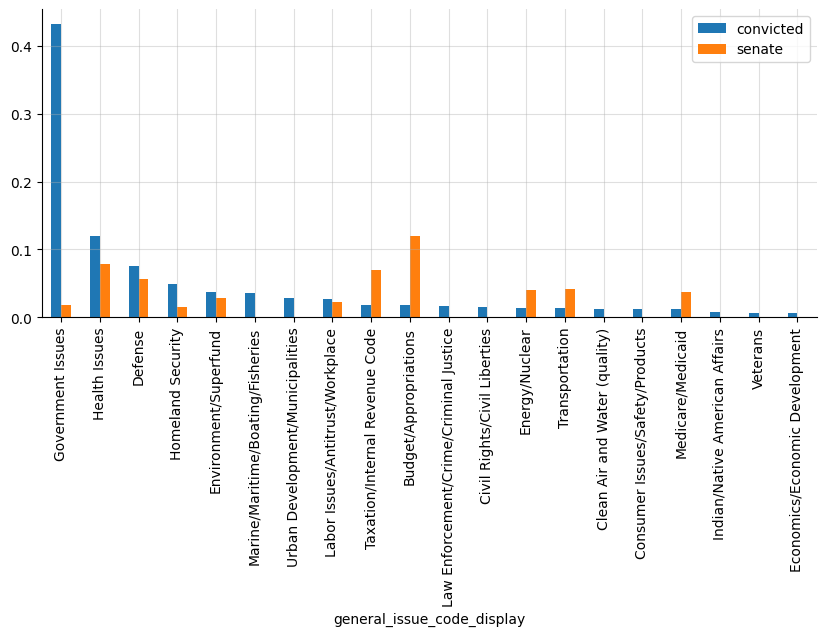

In [84]:
merged = convicted_issues.set_index('general_issue_code_display')[['frac']].rename(columns={'frac': 'convicted'}) \
      .join(senate_issues.set_index('general_issue_code_display')[['frac']].rename(columns={'frac': 'senate'}))

merged.plot(kind='bar')

In [50]:
# House top convicted issues
q("""
  SELECT DISTINCT
      c.lobbyist_name,
      f.organization_name as registrant,
      f.client_name,
      f.filing_year, f.filing_period,
      a.issue_area_code,
      a.description as activity_description,
      c.description as conviction_description
  FROM house_convictions c
  JOIN house_filings f ON f.house_filing_id = c.house_filing_id
  JOIN house_activities a ON a.house_filing_id = f.house_filing_id
  ORDER BY c.lobbyist_name, f.filing_year
  """)["issue_area_code"].value_counts()

issue_area_code
GOV    615
HCR    168
DEF    108
HOM     64
ENV     51
MAR     48
URB     38
LBR     35
TAX     27
LAW     24
BUD     24
CIV     22
ENG     18
TRA     18
CAW     17
CSP     16
MMM     16
VET      9
ECN      9
IND      8
FOO      6
AVI      5
ACC      5
WEL      5
FAM      5
UNM      5
ADV      4
NAT      4
FOR      3
EDU      3
RES      2
RRR      2
AGR      1
CDT      1
FUE      1
MAN      1
HOU      1
Name: count, dtype: int64

# Covered positions

In [86]:
# this table is BY ACTIVITY not by lobbyist, an individual lobbyist appears multiple times
revolvers = q("""
  SELECT 
      l.id as lobbyist_id,
      l.first_name, l.last_name,
      al.covered_position,
      r.name as registrant,
      c.name as client,
      a.general_issue_code_display,
      f.filing_year,
      f.filing_uuid
  FROM senate_activity_lobbyists al
  JOIN senate_lobbyists l ON l.id = al.lobbyist_id
  JOIN senate_lobbying_activities a ON a.activity_id = al.activity_id
  JOIN senate_filings f ON f.filing_uuid = a.filing_uuid
  JOIN senate_registrants r ON r.id = f.registrant_id
  JOIN senate_clients c ON c.id = f.client_id
  WHERE al.covered_position IS NOT NULL
  AND al.covered_position NOT IN ('N/A', 'See prior filing', 'Legislative Consultant', '')
  """)

In [92]:
all_lobbyists = q("""
  SELECT DISTINCT
      r.name as registrant,
      al.lobbyist_id
  FROM senate_activity_lobbyists al
  JOIN senate_lobbying_activities a ON a.activity_id = al.activity_id
  JOIN senate_filings f ON f.filing_uuid = a.filing_uuid
  JOIN senate_registrants r ON r.id = f.registrant_id
  """)

In [87]:
# top firms by distinct revolvers on staff (not normalized -- these might be just large firms)
revolvers.groupby('registrant')['lobbyist_id'].nunique().sort_values(ascending=False).head(20)

registrant
CORNERSTONE GOVERNMENT AFFAIRS, INC.          99
BROWNSTEIN HYATT FARBER SCHRECK, LLP          96
INVARIANT LLC                                 79
AKIN GUMP STRAUSS HAUER & FELD                69
HOLLAND & KNIGHT LLP                          66
BGR GOVERNMENT AFFAIRS                        54
ARNOLD & PORTER KAYE SCHOLER LLP              51
CASSIDY & ASSOCIATES, INC.                    49
SQUIRE PATTON BOGGS                           47
FGS GLOBAL (US) LLC (FKA FGH HOLDINGS LLC)    44
CAPITOL COUNSEL LLC                           41
K&L GATES, LLP                                38
CHAMBER OF COMMERCE OF THE U.S.A.             34
VAN SCOYOC ASSOCIATES                         31
THE RABEN GROUP                               31
MEHLMAN CONSULTING, INC.                      30
MONUMENT ADVOCACY                             29
BOUNDARY STONE PARTNERS                       29
VENABLE LLP                                   28
MICHAEL BEST STRATEGIES LLC                   28
Name: lob

In [93]:
total_per_firm = all_lobbyists.groupby('registrant')['lobbyist_id'].nunique().rename('total')
revolver_per_firm = revolvers.groupby('registrant')['lobbyist_id'].nunique().rename('revolvers')
firm_rates = pd.concat([revolver_per_firm, total_per_firm], axis=1).dropna()
firm_rates['pct_revolvers'] = firm_rates['revolvers'] / firm_rates['total'] * 100

In [98]:
# filter to firms with enough lobbyists to be meaningful, then sort by rate
# these firms have the highest concentration of revolving-door lobbyists
firm_rates[firm_rates['total'] >= 10].sort_values('pct_revolvers', ascending=False).head(30)

,revolvers,total,pct_revolvers
registrant,,,
MILITARY OFFICERS ASSOCIATION OF AMERICA,16.0,16,100.000000
HOLLAND & HART LLP,10.0,10,100.000000
ATLAS CROSSING LLC,11.0,11,100.000000
FOLEY & LARDNER LLP,13.0,13,100.000000
OGR,14.0,14,100.000000
FIERCE GOVERNMENT RELATIONS,10.0,10,100.000000
NATIONAL GUARD ASSOCIATION OF THE UNITED STATES,11.0,11,100.000000
FULCRUM PUBLIC AFFAIRS LLC,11.0,11,100.000000
DISABLED AMERICAN VETERANS,11.0,11,100.000000


In [99]:
revolver_firms = firm_rates[firm_rates['total'] >= 10].sort_values('pct_revolvers', ascending=False).head(50).index

In [100]:
revolvers[revolvers['registrant'].isin(revolver_firms)] \
      .groupby(['registrant', 'general_issue_code_display'])['lobbyist_id'] \
      .nunique() \
      .reset_index() \
      .sort_values(['registrant', 'lobbyist_id'], ascending=[True, False])

,registrant,general_issue_code_display,lobbyist_id
9,"ALPINE GROUP PARTNERS, LLC.",Budget/Appropriations,25
50,"ALPINE GROUP PARTNERS, LLC.",Taxation/Internal Revenue Code,23
37,"ALPINE GROUP PARTNERS, LLC.",Manufacturing,21
1,"ALPINE GROUP PARTNERS, LLC.",Agriculture,20
17,"ALPINE GROUP PARTNERS, LLC.",Defense,20
...,...,...,...
1555,WINDWARD STRATEGIES,Economics/Economic Development,2
1560,WINDWARD STRATEGIES,Urban Development/Municipalities,2
1556,WINDWARD STRATEGIES,Education,1
1557,WINDWARD STRATEGIES,Environment/Superfund,1


In [101]:
revolvers[revolvers['registrant'].isin(revolver_firms)] \
      .groupby(['registrant', 'general_issue_code_display'])['lobbyist_id'] \
      .nunique() \
      .unstack(fill_value=0)

general_issue_code_display,Accounting,Advertising,Aerospace,Agriculture,Alcohol and Drug Abuse,Animals,Apparel/Clothing Industry/Textiles,Arts/Entertainment,Automotive Industry,Aviation/Airlines/Airports,Banking,Bankruptcy,Beverage Industry,Budget/Appropriations,Chemicals/Chemical Industry,Civil Rights/Civil Liberties,Clean Air and Water (quality),Commodities (big ticket),Communications/Broadcasting/Radio/TV,Computer Industry,Constitution,Consumer Issues/Safety/Products,Copyright/Patent/Trademark,Defense,Disaster Planning/Emergencies,District of Columbia,Economics/Economic Development,Education,Energy/Nuclear,Environment/Superfund,Family issues/Abortion/Adoption,Financial Institutions/Investments/Securities,Firearms/Guns/Ammunition,"Food Industry (safety, labeling, etc.)",Foreign Relations,Fuel/Gas/Oil,Gaming/Gambling/Casino,Government Issues,Health Issues,Homeland Security,Housing,Immigration,Indian/Native American Affairs,Insurance,Intelligence,Labor Issues/Antitrust/Workplace,Law Enforcement/Crime/Criminal Justice,Manufacturing,Marine/Maritime/Boating/Fisheries,Media (information/publishing),Medical/Disease Research/Clinical Labs,Medicare/Medicaid,Minting/Money/Gold Standard,Natural Resources,Pharmacy,Postal,Railroads,Real Estate/Land Use/Conservation,Retirement,Roads/Highway,Science/Technology,Small Business,Sports/Athletics,Tariff (miscellaneous tariff bills),Taxation/Internal Revenue Code,Telecommunications,Tobacco,Torts,Trade (domestic/foreign),Transportation,Travel/Tourism,Trucking/Shipping,Unemployment,Urban Development/Municipalities,Utilities,Veterans,Waste (hazardous/solid/interstate/nuclear),Welfare
registrant,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"ALPINE GROUP PARTNERS, LLC.",0,0,6,20,4,0,0,3,13,16,6,5,4,25,11,0,10,5,14,16,0,14,4,20,6,0,8,9,20,20,0,12,0,9,5,15,0,9,19,14,9,8,1,7,8,3,8,21,10,0,9,12,6,5,8,0,6,5,0,7,18,3,0,8,23,17,2,0,18,19,2,0,0,7,9,14,0,0
ATLAS CROSSING LLC,0,0,0,8,0,10,0,0,0,11,4,0,0,10,0,0,0,0,0,0,0,0,0,11,6,0,0,11,11,0,0,7,0,11,0,0,0,11,11,0,7,9,0,0,0,6,0,11,6,0,0,0,0,0,0,0,0,9,0,0,11,4,0,0,10,0,0,0,6,11,4,0,0,0,0,4,0,0
"AVOQ, LLC",1,4,0,8,0,0,0,3,8,6,9,0,3,16,0,3,0,0,8,9,0,11,7,4,3,0,5,4,5,3,0,12,4,9,3,1,5,5,13,3,3,5,0,3,0,9,4,10,0,0,7,6,0,0,0,0,0,0,11,0,17,6,0,0,14,12,1,0,11,4,1,0,1,0,0,0,0,4
"BANNER PUBLIC AFFAIRS, LLC",0,0,0,5,0,0,0,2,4,0,2,0,2,7,0,0,8,0,0,0,0,4,0,6,1,0,3,6,7,5,0,2,0,0,1,0,0,0,6,1,3,0,0,0,0,2,0,5,1,0,0,0,0,6,3,0,0,2,0,0,6,4,0,3,6,0,0,0,6,2,0,0,0,0,0,0,0,0
BGR GOVERNMENT AFFAIRS,1,0,4,11,0,8,0,0,8,21,11,5,2,30,0,0,0,0,5,16,0,11,12,26,0,0,8,31,32,16,0,21,0,20,24,4,6,35,37,0,13,12,0,12,0,15,5,19,3,0,7,18,0,5,13,5,6,0,4,0,22,7,0,17,33,22,5,0,32,27,0,0,0,0,3,16,1,0
BIPARTISAN POLICY CENTER ACTION,0,0,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,5,6,0,4,4,0,0,0,0,0,3,4,0,2,2,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,3,0,4,0,0,0,10,0,0,0,0,5,0,0,0,0,0,0,0,0
CAPITOL COUNSEL LLC,0,5,1,14,0,6,1,0,3,2,12,0,0,25,6,0,6,1,3,3,0,8,2,7,0,0,4,11,18,9,1,20,2,6,11,0,0,12,27,4,2,0,3,4,0,1,8,3,6,7,9,15,0,7,9,0,0,0,10,1,4,0,13,1,25,7,0,0,8,8,3,2,0,3,7,4,0,0
CAPITOL HILL CONSULTING GROUP,0,0,0,2,0,2,0,0,0,1,0,4,0,5,1,0,1,0,0,0,0,0,4,8,3,0,2,1,5,3,0,1,0,4,0,1,0,2,8,1,3,1,2,0,0,3,0,7,4,0,4,7,0,5,6,0,1,1,0,2,1,1,0,0,5,3,0,0,8,8,1,1,0,3,1,5,3,0
"CASSIDY & ASSOCIATES, INC.",0,2,6,8,0,0,0,0,1,5,3,0,0,46,2,0,13,0,7,8,0,6,0,39,4,0,10,28,24,24,1,6,1,0,0,2,0,27,15,12,2,0,3,6,13,5,7,19,4,0,1,1,0,29,10,0,2,13,0,3,15,7,5,1,17,14,0,0,12,20,1,0,3,0,7,5,7,0


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 [Text(0, 0, 'Budget/Appropriations'),
  Text(1, 0, 'Health Issues'),
  Text(2, 0, 'Taxation/Internal Revenue Code'),
  Text(3, 0, 'Defense'),
  Text(4, 0, 'Medicare/Medicaid'),
  Text(5, 0, 'Energy/Nuclear'),
  Text(6, 0, 'Transportation'),
  Text(7, 0, 'Financial Institutions/Investments/Securities'),
  Text(8, 0, 'Trade (domestic/foreign)'),
  Text(9, 0, 'Environment/Superfund'),
  Text(10, 0, 'Science/Technology'),
  Text(11, 0, 'Agriculture'),
  Text(12, 0, 'Education'),
  Text(13, 0, 'Natural Resources'),
  Text(14, 0, 'Labor Issues/Antitrust/Workplace'),
  Text(15, 0, 'Banking'),
  Text(16, 0, 'Telecommunications'),
  Text(17, 0, 'Aviation/Airlines/Airports'),
  Text(18, 0, 'Homeland Security'),
  Text(19, 0, 'Government Issues')])

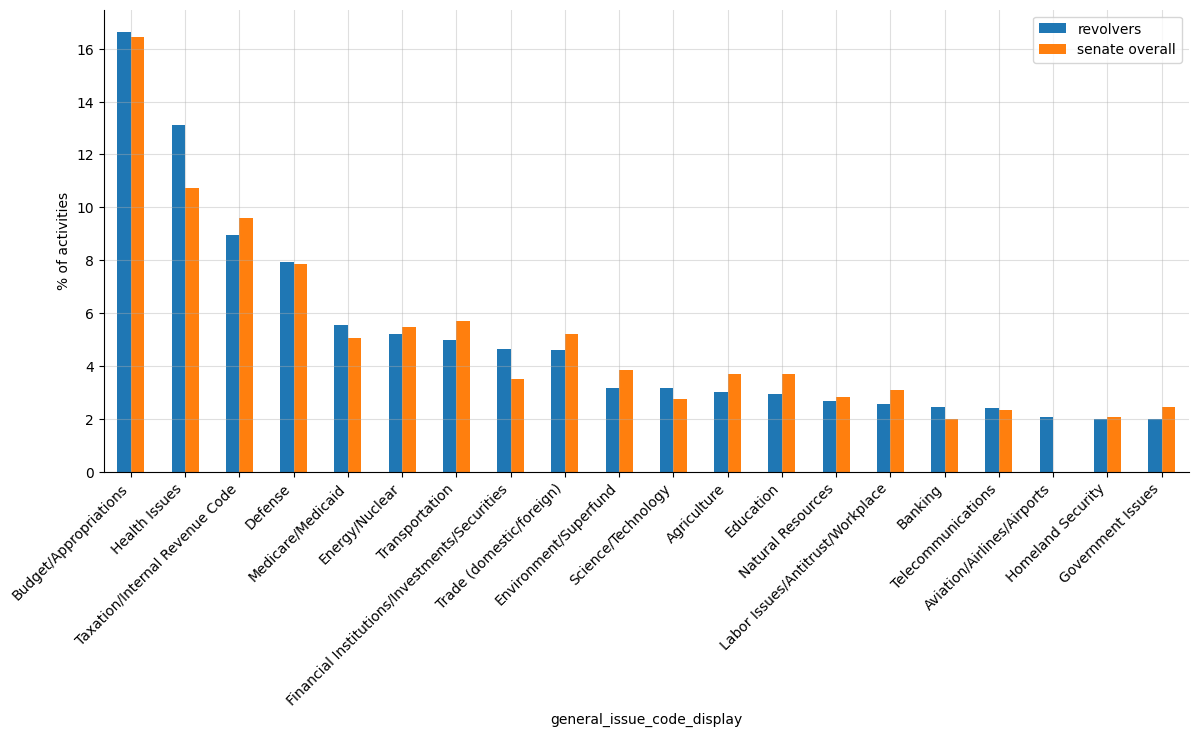

In [105]:
# how revolver issues compare to overall
senate_issue_pct = q("""
  SELECT general_issue_code_display, COUNT(*) as n
  FROM senate_lobbying_activities
  GROUP BY general_issue_code_display
  ORDER BY n DESC
  LIMIT 20
  """)
  
revolver_issue_pct = revolvers['general_issue_code_display'].value_counts().reset_index()
revolver_issue_pct.columns = ['general_issue_code_display', 'n']
revolver_issue_pct = revolver_issue_pct.head(20)

senate_issue_pct['pct'] = senate_issue_pct['n'] / senate_issue_pct['n'].sum() * 100
revolver_issue_pct['pct'] = revolver_issue_pct['n'] / revolver_issue_pct['n'].sum() * 100

merged = revolver_issue_pct.set_index('general_issue_code_display')[['pct']] \
  .rename(columns={'pct': 'revolvers'}) \
  .join(senate_issue_pct.set_index('general_issue_code_display')[['pct']] \
  .rename(columns={'pct': 'senate overall'}))

merged.plot(kind='bar', figsize=(14, 6))
plt.ylabel('% of activities')
plt.xticks(rotation=45, ha='right')

Text(0.5, 1.0, 'Number of revolving door activities')

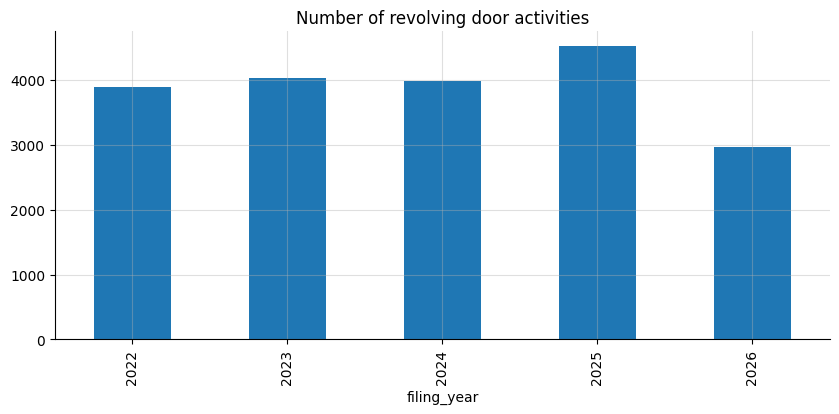

In [91]:
# by year — is revolving door growing?
revolvers.groupby('filing_year')['lobbyist_id'].nunique().plot.bar()
plt.title("Number of revolving door activities")

In [106]:
##We need to compare each firm's revolver issue mix against the Senate baseline. A simple approach is to compute an
 ## "overrepresentation ratio" — firm's share of an issue divided by Senate's share of that issue:

# Senate baseline shares
senate_baseline = q("""
SELECT general_issue_code_display, COUNT(*) as n
FROM senate_lobbying_activities
GROUP BY general_issue_code_display
""")
senate_baseline['share'] = senate_baseline['n'] / senate_baseline['n'].sum()
senate_baseline = senate_baseline.set_index('general_issue_code_display')['share']

# firm issue mix — activities (not distinct lobbyists, so we capture volume)
firm_issues = revolvers[revolvers['registrant'].isin(revolver_firms)] \
  .groupby(['registrant', 'general_issue_code_display']).size() \
  .unstack(fill_value=0)

# normalize each row to shares
firm_shares = firm_issues.div(firm_issues.sum(axis=1), axis=0)

# divide by senate baseline — values >> 1 mean overrepresented
overrep = firm_shares.div(senate_baseline, axis=1)

# for each firm, find their most overrepresented issue
overrep.stack().reset_index() \
  .rename(columns={0: 'ratio', 'level_1': 'general_issue_code_display'}) \
  .sort_values(['registrant', 'ratio'], ascending=[True, False]) \
  .drop_duplicates('registrant') \
  .sort_values('ratio', ascending=False)

# A ratio of 5 means that firm's revolvers work on that issue 5x more than you'd expect given how common it is in the
# Senate overall.

,registrant,general_issue_code_display,ratio
945,DISABLED AMERICAN VETERANS,Veterans,103.003481
3919,WINDWARD STRATEGIES,Marine/Maritime/Boating/Fisheries,58.897096
785,"CLYBURN CONSULTING, LLC",Urban Development/Municipalities,55.822788
2246,KYLE HOUSE GROUP,Foreign Relations,39.361408
1289,FIERCE GOVERNMENT RELATIONS,District of Columbia,37.616280
3098,RICH FEUER ANDERSON,Commodities (big ticket),36.880131
2525,MILITARY OFFICERS ASSOCIATION OF AMERICA,Veterans,34.334494
1614,GENERAL ATOMICS,Foreign Relations,30.832581
2906,NOVEL STRATEGIES (FKA) PRISM GROUP,Small Business,27.349893
1852,HOLLAND & HART LLP,Fuel/Gas/Oil,26.783971


The above list mostly shows what firms specialize in. We might like to surface ex-government staff that lobby in the same issue area they once worked in in their government position.

A simpler filter that might get you closer: restrict to multi-issue firms (firms that lobby across many issue areas)
and then look for overrepresentation. A generalist firm that happens to punch way above its weight on Defense is more
suspicious than a defense-only boutique:

In [107]:
# only keep firms that lobby across many issue areas
issue_diversity = firm_issues[firm_issues > 0].count(axis=1)

diverse_firms = issue_diversity[issue_diversity >= 10].index

overrep.loc[diverse_firms].stack().reset_index() \
  .rename(columns={0: 'ratio', 'level_1': 'issue'}) \
  .sort_values(['registrant', 'ratio'], ascending=[True, False]) \
  .drop_duplicates('registrant') \
  .sort_values('ratio', ascending=False)

,registrant,general_issue_code_display,ratio
1131,FIERCE GOVERNMENT RELATIONS,District of Columbia,37.616280
2466,RICH FEUER ANDERSON,Commodities (big ticket),36.880131
2274,NOVEL STRATEGIES (FKA) PRISM GROUP,Small Business,27.349893
1536,HOLLAND & HART LLP,Fuel/Gas/Oil,26.783971
564,CAPITOL HILL CONSULTING GROUP,Bankruptcy,25.302540
425,BIPARTISAN POLICY CENTER ACTION,Family issues/Abortion/Adoption,25.101648
3087,"VENTURE GOVERNMENT STRATEGIES, LLC (FKA HOBART...",Apparel/Clothing Industry/Textiles,21.532272
1090,FGS GLOBAL (US) LLC (FKA FGH HOLDINGS LLC),Sports/Athletics,20.836831
2682,STRATEGIES 360,Utilities,20.833281
1274,FS VECTOR LLC,Banking,17.648574
